In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan agar kolom tidak terpotong
pd.set_option('display.max_columns', None)

# Lokasi file di Kaggle
PATH = '/kaggle/input/store-sales-time-series-forecasting/'

# 1. Memuat Data Utama (Penjualan)
# Penting: parse_dates mengubah teks '2013-01-01' menjadi objek Waktu
df_train = pd.read_csv(PATH + 'train.csv', parse_dates=['date'])
df_test = pd.read_csv(PATH + 'test.csv', parse_dates=['date'])

# 2. Memuat Data Pendukung (Konteks Ekonomi & Lokasi)
df_oil = pd.read_csv(PATH + 'oil.csv', parse_dates=['date'])
df_holidays = pd.read_csv(PATH + 'holidays_events.csv', parse_dates=['date'])
df_stores = pd.read_csv(PATH + 'stores.csv')
df_trans = pd.read_csv(PATH + 'transactions.csv', parse_dates=['date'])

print("Data berhasil dimuat!")
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Oil shape: {df_oil.shape}")
print(f"Holidays shape: {df_holidays.shape}")
print(f"Stores shape: {df_stores.shape}")

Data berhasil dimuat!
Train shape: (3000888, 6)
Test shape: (28512, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)
Stores shape: (54, 5)


In [2]:
# 1. Mengintip isi data utama
print("--- CONTOH DATA TRANSAKSI ---")
print(df_train.head())

# 2. Cek Rentang Waktu 
print("\n--- RENTANG WAKTU ---")
print(f"Data Latih : {df_train.date.min()} s/d {df_train.date.max()}")
print(f"Data Uji   : {df_test.date.min()} s/d {df_test.date.max()}")

# 3. Cek Data Hilang pada Minyak (Oil Price)
print("\n--- DATA HILANG (OIL) ---")
print(df_oil.isnull().sum())

# 4. Cek Jumlah Toko dan Produk
print("\n--- STATISTIK ---")
print(f"Jumlah Toko Unik   : {df_train.store_nbr.nunique()}")
print(f"Jenis Produk (Family): {df_train.family.nunique()}")

--- CONTOH DATA TRANSAKSI ---
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

--- RENTANG WAKTU ---
Data Latih : 2013-01-01 00:00:00 s/d 2017-08-15 00:00:00
Data Uji   : 2017-08-16 00:00:00 s/d 2017-08-31 00:00:00

--- DATA HILANG (OIL) ---
date           0
dcoilwtico    43
dtype: int64

--- STATISTIK ---
Jumlah Toko Unik   : 54
Jenis Produk (Family): 33


In [3]:
# 1. Menggabungkan (Merge) Data Minyak & Info Toko
df_train = df_train.merge(df_oil, on='date', how='left')
df_train = df_train.merge(df_stores, on='store_nbr', how='left')

df_test = df_test.merge(df_oil, on='date', how='left')
df_test = df_test.merge(df_stores, on='store_nbr', how='left')

# 2. Menambal Harga Minyak yang Bolong
# Karena pasar libur weekend, pakai harga hari sebelumnya (ffill)
# Jika data paling awal kosong, pakai harga besoknya (bfill)
df_train['dcoilwtico'] = df_train['dcoilwtico'].ffill().bfill()
df_test['dcoilwtico'] = df_test['dcoilwtico'].ffill().bfill()

# 3. Rename 
df_train = df_train.rename(columns={'dcoilwtico': 'oil_price', 'type': 'store_type'})
df_test = df_test.rename(columns={'dcoilwtico': 'oil_price', 'type': 'store_type'})

print("Penyatuan data selesai!")
print(f"Data kosong di Minyak: {df_train['oil_price'].isnull().sum()}")
display(df_train.head())

Penyatuan data selesai!
Data kosong di Minyak: 0


,id,date,store_nbr,family,sales,onpromotion,oil_price,city,state,store_type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,93.14,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,93.14,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,93.14,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,93.14,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,93.14,Quito,Pichincha,D,13


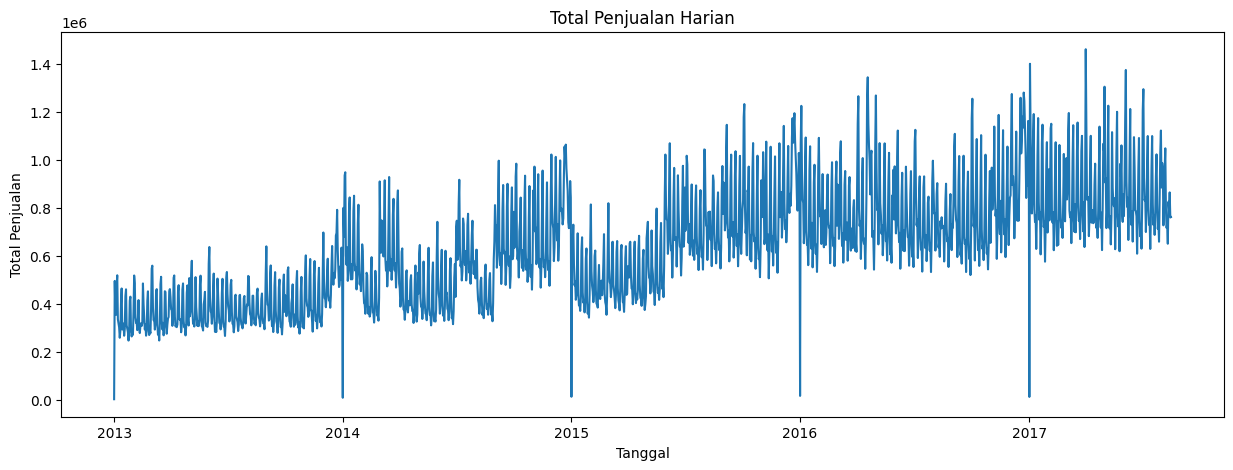

In [4]:
sales_trend = df_train.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(15, 5))
plt.plot(sales_trend['date'], sales_trend['sales'])
plt.title('Total Penjualan Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan')
plt.show()

In [5]:
# Fungsi untuk mengekstrak komponen tanggal
def create_date_features(df):
    df['year'] = df.date.dt.year
    df['month'] = df.date.dt.month
    df['day'] = df.date.dt.day
    df['dayofweek'] = df.date.dt.dayofweek # Senin=0, Minggu=6
    
    # Membuat fitur khusus: Apakah hari ini akhir pekan? (1=Ya, 0=Tidak)
    df['is_weekend'] = (df.date.dt.dayofweek >= 5).astype(int)
    
    return df

# Terapkan fungsi ke data latih dan data uji
df_train = create_date_features(df_train)
df_test = create_date_features(df_test)

print("Fitur waktu berhasil dibuat!")
display(df_train[['date', 'year', 'month', 'day', 'dayofweek', 'is_weekend']].head())

Fitur waktu berhasil dibuat!


,date,year,month,day,dayofweek,is_weekend
0,2013-01-01,2013,1,1,1,0
1,2013-01-01,2013,1,1,1,0
2,2013-01-01,2013,1,1,1,0
3,2013-01-01,2013,1,1,1,0
4,2013-01-01,2013,1,1,1,0


In [6]:
df_holidays = df_holidays[df_holidays.transferred == False]
df_holidays['is_holiday'] = 1
holiday_data = df_holidays[['date', 'is_holiday']].drop_duplicates('date')

df_train = df_train.merge(holiday_data, on='date', how='left')
df_test = df_test.merge(holiday_data, on='date', how='left')

df_train['is_holiday'] = df_train['is_holiday'].fillna(0)
df_test['is_holiday'] = df_test['is_holiday'].fillna(0)

print(df_train['is_holiday'].value_counts())

is_holiday
0.0    2567862
1.0     433026
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

kolom_teks = ['family', 'city', 'state', 'store_type']
mesin_sandi = LabelEncoder()

for teks in kolom_teks:
    df_train[teks] = mesin_sandi.fit_transform(df_train[teks].astype(str))
    df_test[teks] = mesin_sandi.transform(df_test[teks].astype(str))

kolom_buang = ['date', 'transferred', 'description', 'locale', 'locale_name']
df_train = df_train.drop(columns=kolom_buang, errors='ignore')
df_test = df_test.drop(columns=kolom_buang, errors='ignore')

X_train = df_train.drop(columns=['sales', 'id'], errors='ignore')
y_train = df_train['sales']
X_test = df_test.drop(columns=['id'], errors='ignore')

print("Data siap diproses")
print(X_train.head())

Data siap diproses
   store_nbr  family  onpromotion  oil_price  city  state  store_type  \
0          1       0            0      93.14    18     12           3   
1          1       1            0      93.14    18     12           3   
2          1       2            0      93.14    18     12           3   
3          1       3            0      93.14    18     12           3   
4          1       4            0      93.14    18     12           3   

   cluster  year  month  day  dayofweek  is_weekend  is_holiday  
0       13  2013      1    1          1           0         1.0  
1       13  2013      1    1          1           0         1.0  
2       13  2013      1    1          1           0         1.0  
3       13  2013      1    1          1           0         1.0  
4       13  2013      1    1          1           0         1.0  


In [8]:
import xgboost as xgb
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)
prediksi = model.predict(X_test)
print("Pelatihan model selesai")

Pelatihan model selesai


In [9]:
import pandas as pd
submission = pd.DataFrame()
submission['id'] = df_test['id']
submission['sales'] = prediksi
submission['sales'] = submission['sales'].clip(lower=0)
submission.to_csv('submission.csv', index=False)
print("Selesai")

Selesai
